In [126]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, precision_recall_curve, recall_score, f1_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [127]:
df_train = pd.read_csv('adult.data.csv', skipinitialspace=True, na_values="?")
print(df_train.shape)
df_train.head()

(32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [128]:
df_test = pd.read_csv('adult.test.csv', skipinitialspace=True, na_values="?")
print(df_test.shape)
df_test.head()

(16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [129]:
df = pd.concat([df_train, df_test], ignore_index=True)
print(df.shape)
df

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [130]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [131]:
df.dropna(inplace=True)
df.nunique()

age                  74
workclass             7
fnlwgt            26741
education            16
education-num        16
marital-status        7
occupation           14
relationship          6
race                  5
sex                   2
capital-gain        121
capital-loss         97
hours-per-week       96
native-country       41
income                2
dtype: int64

In [132]:
# Так как классификация бинарная, переведем целевую переменную в числовой формат: 0, 1
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

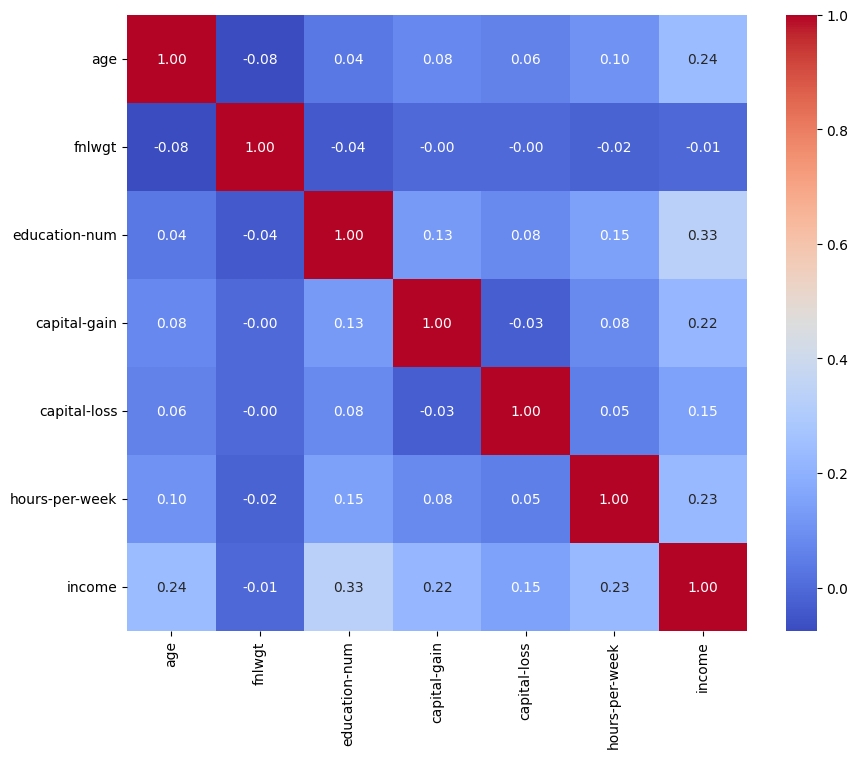

In [133]:
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [134]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
count,45222.000000,4.522200e+04,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1.897347e+05,10.118460,1101.430344,88.595418,40.938017,0.247844
std,13.217870,1.056392e+05,2.552881,7506.430084,404.956092,12.007508,0.431766
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.173882e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783160e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,2.379260e+05,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


## Выводы по анализу датасета
Признак fnlwgt очень слабо коррелирует с целевой переменной, а также у него очень много уникальных значений. Можно удалить.
Также, education_num является отображением education, поэтому один из признаков можно удалить.

In [135]:
df.drop(columns=['fnlwgt', 'education'], axis=1, inplace=True)

In [136]:
categorical_cols = [
    'workclass', 'marital-status',
    'occupation', 'relationship', 'race',
    'sex', 'native-country'
]

df = pd.get_dummies(df, columns=categorical_cols)

print(df.shape)
df

(45222, 88)


,age,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,2174,0,40,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,13,0,0,13,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,9,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,53,7,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,28,13,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,13,0,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
48837,39,13,0,0,36,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
48839,38,13,0,0,50,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
48840,44,13,5455,0,40,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [137]:
from sklearn.discriminant_analysis import StandardScaler


numeric_features = ['age', 'education-num', 
                    'capital-gain', 'capital-loss', 'hours-per-week']

scaler = StandardScaler()

df[numeric_features] = scaler.fit_transform(df[numeric_features])
df.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.034201,1.128753,0.142888,-0.21878,-0.078120,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.866417,1.128753,-0.146733,-0.21878,-2.326738,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.041455,-0.438122,-0.146733,-0.21878,-0.078120,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,1.093385,-1.221559,-0.146733,-0.21878,-0.078120,0,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,-0.798015,1.128753,-0.146733,-0.21878,-0.078120,0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [138]:
df[numeric_features].describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,4.522200e+04,4.522200e+04,4.522200e+04,4.522200e+04,4.522200e+04
mean,-2.513972e-17,1.590087e-16,-4.085204e-18,1.398397e-17,2.235864e-16
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00
min,-1.630231e+00,-3.571870e+00,-1.467332e-01,-2.187803e-01,-3.326124e+00
25%,-7.980149e-01,-4.381216e-01,-1.467332e-01,-2.187803e-01,-7.812006e-02
50%,-1.171110e-01,-4.640300e-02,-1.467332e-01,-2.187803e-01,-7.812006e-02
75%,6.394489e-01,1.128753e+00,-1.467332e-01,-2.187803e-01,3.382907e-01
max,3.892656e+00,2.303909e+00,1.317519e+01,1.053806e+01,4.835527e+00


In [139]:
from xgboost import XGBClassifier


X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=52, stratify=y
)

results = []

for n in range(50, 101, 10):
    model = XGBClassifier(
                                n_estimators=n,
                                learning_rate=0.1,
                                max_depth=7,
                                random_state=52
    )

    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_threshold = thresholds[np.argmax(f1_scores)]

    y_pred = (y_proba >= best_threshold).astype(int)
    # y_pred = model.predict(X_test)

    results.append({
        'n_estimators': n,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-score': f1_score(y_test, y_pred, average='macro'),
    })

results_df = pd.DataFrame(results)
results_df

,n_estimators,Accuracy,Precision,Recall,F1-score
0,50,0.870647,0.828502,0.820709,0.824476
1,60,0.870426,0.827928,0.821160,0.824446
2,70,0.871863,0.829706,0.823611,0.826579
3,80,0.871752,0.828799,0.825631,0.827193
4,90,0.869652,0.824170,0.828869,0.826471
5,100,0.871200,0.827828,0.825562,0.826684


              precision    recall  f1-score   support

       <=50K       0.91      0.92      0.91      6803
        >50K       0.74      0.74      0.74      2242

    accuracy                           0.87      9045
   macro avg       0.83      0.83      0.83      9045
weighted avg       0.87      0.87      0.87      9045



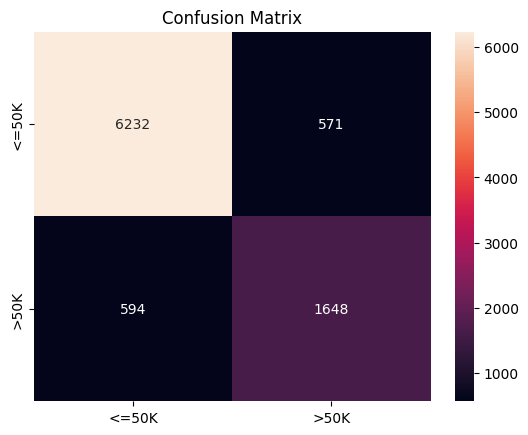

Распределение классов:
income
0    0.752156
1    0.247844
Name: proportion, dtype: float64


In [140]:
from sklearn.metrics import classification_report, confusion_matrix


print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['<=50K', '>50K'], 
            yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix')
plt.show()

# Распределение классов
print("Распределение классов:")
print(pd.Series(y).value_counts(normalize=True))

In [141]:
import json

with open('nb_results.json', 'r') as f:
    nb_results = json.load(f)

with open('dt_results.json', 'r') as f:
    dt_results = json.load(f)

with open('bg_results.json', 'r') as f:
    bg_results = json.load(f)

with open('rf_results.json', 'r') as f:
    rf_results = json.load(f)

nb_results_df = pd.DataFrame(nb_results)
dt_results_df = pd.DataFrame(dt_results)
bg_results_df = pd.DataFrame(bg_results)
rf_results_df = pd.DataFrame(rf_results)

nb_result_df = nb_results_df[np.isclose(nb_results_df["Train Size"], 0.8)]
dt_result_df = dt_results_df[np.isclose(dt_results_df["Train Size"], 0.8)]
bg_result_df = bg_results_df[np.isclose(bg_results_df["n_estimators"], 100)]
rf_result_df = rf_results_df[np.isclose(rf_results_df["n_estimators"], 100)]

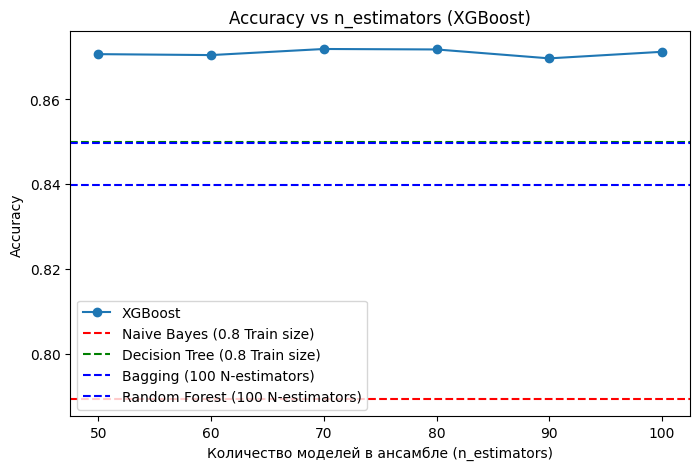

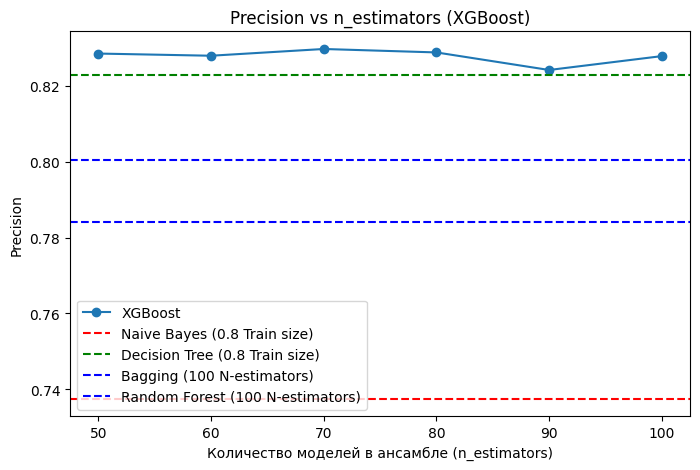

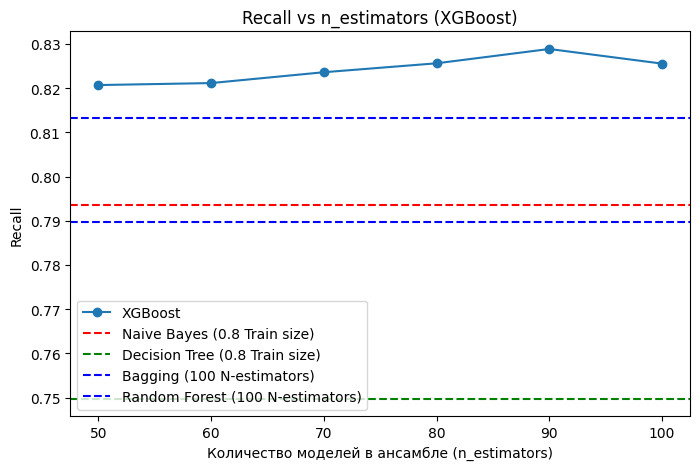

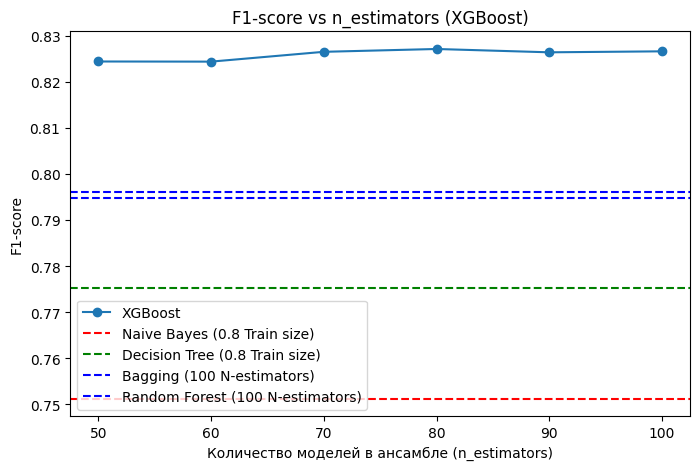

In [142]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

for metric in metrics:
    plt.figure(figsize=(8,5))
    plt.plot(results_df['n_estimators'], results_df[metric], marker='o', label='XGBoost')

    plt.axhline(nb_result_df[metric].values[0], color='r', linestyle='--', label='Naive Bayes (0.8 Train size)')
    plt.axhline(dt_result_df[metric].values[0], color='g', linestyle='--', label='Decision Tree (0.8 Train size)')
    plt.axhline(bg_result_df[metric].values[0], color='b', linestyle='--', label='Bagging (100 N-estimators)')
    plt.axhline(rf_result_df[metric].values[0], color='b', linestyle='--', label='Random Forest (100 N-estimators)')

    plt.xlabel('Количество моделей в ансамбле (n_estimators)')
    plt.ylabel(metric)
    plt.title(f'{metric} vs n_estimators (XGBoost)')
    plt.legend()
    plt.savefig(f'{metric}_xgboost_comparison.png')
    plt.show()